# AI-Based Weapon Detection using YOLO + Roboflow Dataset

**Lab Notebook for Google Colab**

## Objective
Train a custom YOLO model for **weapon detection** using a **Roboflow dataset** and **Ultralytics YOLO**.

## Safety and Ethics Note
This notebook is for **educational and public safety research only**. Weapon detection systems can produce false positives and false negatives. Human verification is always required.

## Workflow

```text
Roboflow Dataset → Download YOLOv8 Format → Train YOLO → Evaluate → Test → Save Model
```

## Step 1: Install Required Libraries

In [ ]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.2 MB/s eta 0:00:00


## Step 2: Import Libraries

In [ ]:
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
from google.colab import files

import os, glob, yaml
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.


## Step 3: Connect Roboflow Dataset

Replace the placeholders with your Roboflow details.

How to get this:
1. Open your Roboflow project.
2. Click **Download Dataset**.
3. Select **YOLOv8** format.
4. Copy your workspace, project, version, and API key.

Example:
```python
rf = Roboflow(api_key="abc123")
project = rf.workspace("my-workspace").project("weapon-detection")
version = project.version(1)
dataset = version.download("yolov8")
```

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="vvnltDQnN21B7ClLPQN4")
project = rf.workspace("maheshchhetri").project("weapon-detection-e6otc")
version = project.version(3)
dataset = version.download("yolov11")



print("Dataset downloaded at:", dataset.location)

print("Dataset downloaded successfully.")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to weapon-detection-3 in yolov11:: 100%|██████████| 3738/3738 [00:00<00:00, 7691.20it/s]

Dataset downloaded at: /content/weapon-detection-3
Dataset downloaded successfully.
Dataset location: /content/weapon-detection-3


## Step 4: Check Dataset Files

In [ ]:
dataset_path = dataset.location
data_yaml_path = os.path.join(dataset_path, "data.yaml")

print("Dataset path:", dataset_path)
print("data.yaml exists:", os.path.exists(data_yaml_path))

print("\nDataset folder content:")
for item in os.listdir(dataset_path):
    print("-", item)

Dataset path: /content/weapon-detection-3
data.yaml exists: True

Dataset folder content:
- README.roboflow.txt
- train
- valid
- README.dataset.txt
- data.yaml
- test


## Step 5: Read `data.yaml` and Class Names

In [ ]:
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

class_names = data_yaml.get("names", [])
print("\nClasses:", class_names)
print("Number of classes:", len(class_names))

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['Handgun', 'Knife', 'Rifle', 'Sword'], 'roboflow': {'workspace': 'maheshchhetri', 'project': 'weapon-detection-e6otc', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/maheshchhetri/weapon-detection-e6otc/dataset/3'}}

Classes: ['Handgun', 'Knife', 'Rifle', 'Sword']
Number of classes: 4


## Step 6: Count Images in Train, Validation, and Test Sets

In [ ]:
def count_images(folder):
    exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
    return sum(len(glob.glob(os.path.join(folder, ext))) for ext in exts)

train_img_dir = os.path.join(dataset_path, "train", "images")
valid_img_dir = os.path.join(dataset_path, "valid", "images")
test_img_dir = os.path.join(dataset_path, "test", "images")

counts = {
    "Train Images": count_images(train_img_dir),
    "Validation Images": count_images(valid_img_dir),
    "Test Images": count_images(test_img_dir)
}

pd.DataFrame([counts])

,Train Images,Validation Images,Test Images
0,1356,232,275


## Step 7: Preview Sample Training Images

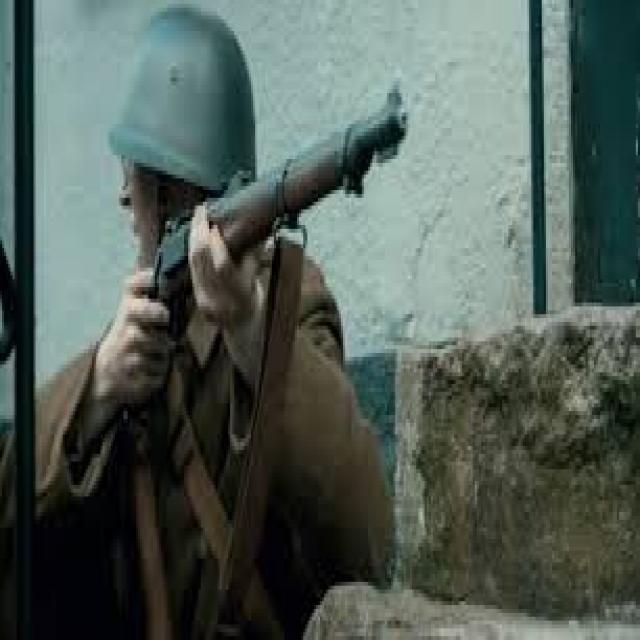

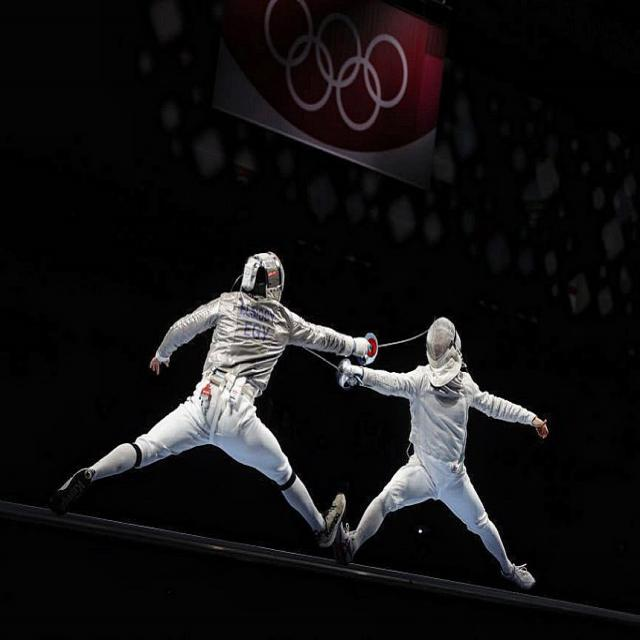

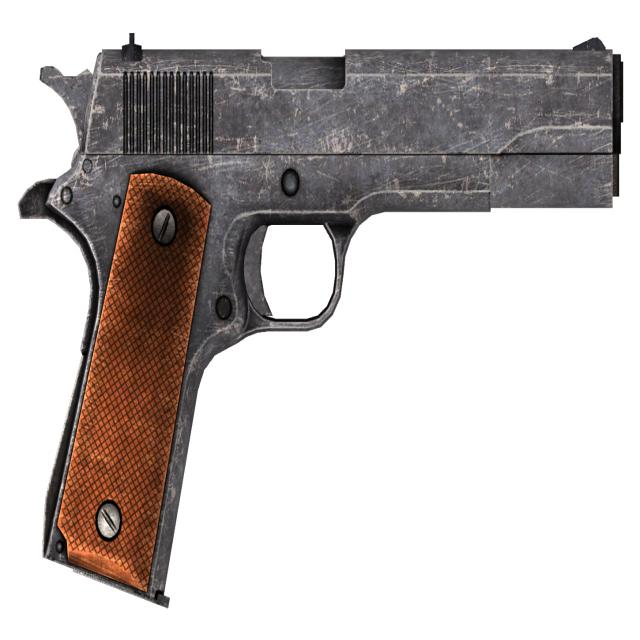

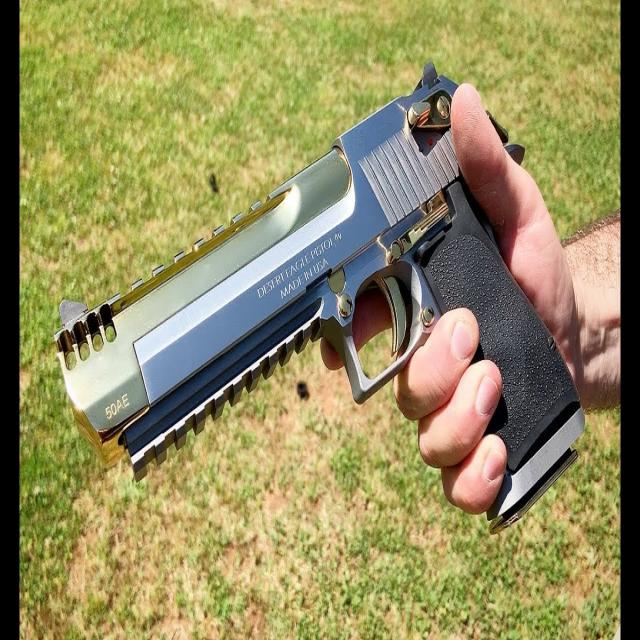

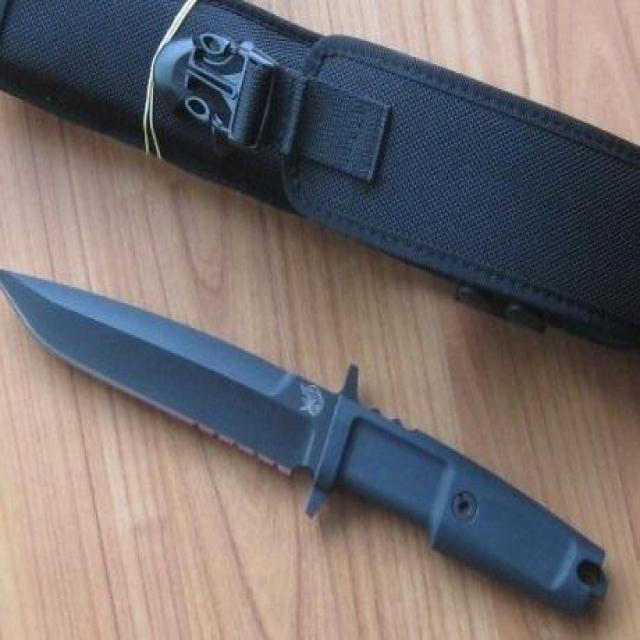

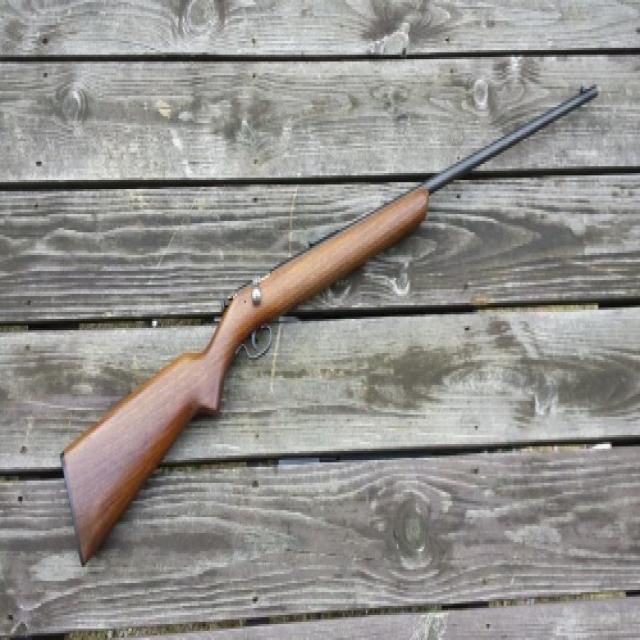

In [ ]:
sample_images = glob.glob(os.path.join(train_img_dir, "*"))[:6]

for img in sample_images:
    display(Image(filename=img, width=400))

## Step 8: Load Pretrained YOLO Model

Recommended for lab:
- `yolov8n.pt` = fast and lightweight
- `yolov8s.pt` = better accuracy but slower

In [ ]:
model = YOLO("yolov8n.pt")
print("YOLOv8 nano model loaded successfully.")

YOLOv8 nano model loaded successfully.


## Step 9: Train Weapon Detection Model

In [ ]:
results = model.train(
    data=data_yaml_path,
    epochs=15,
    imgsz=640,
    batch=8,
    name="weapon_detection_yolov8_roboflow"
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/weapon-detection-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weapon_detection_yolov8_roboflow, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

## Step 10: Display Training Results

Important files:
- `results.png`
- `confusion_matrix.png`
- `PR_curve.png`
- `F1_curve.png`


 results.png


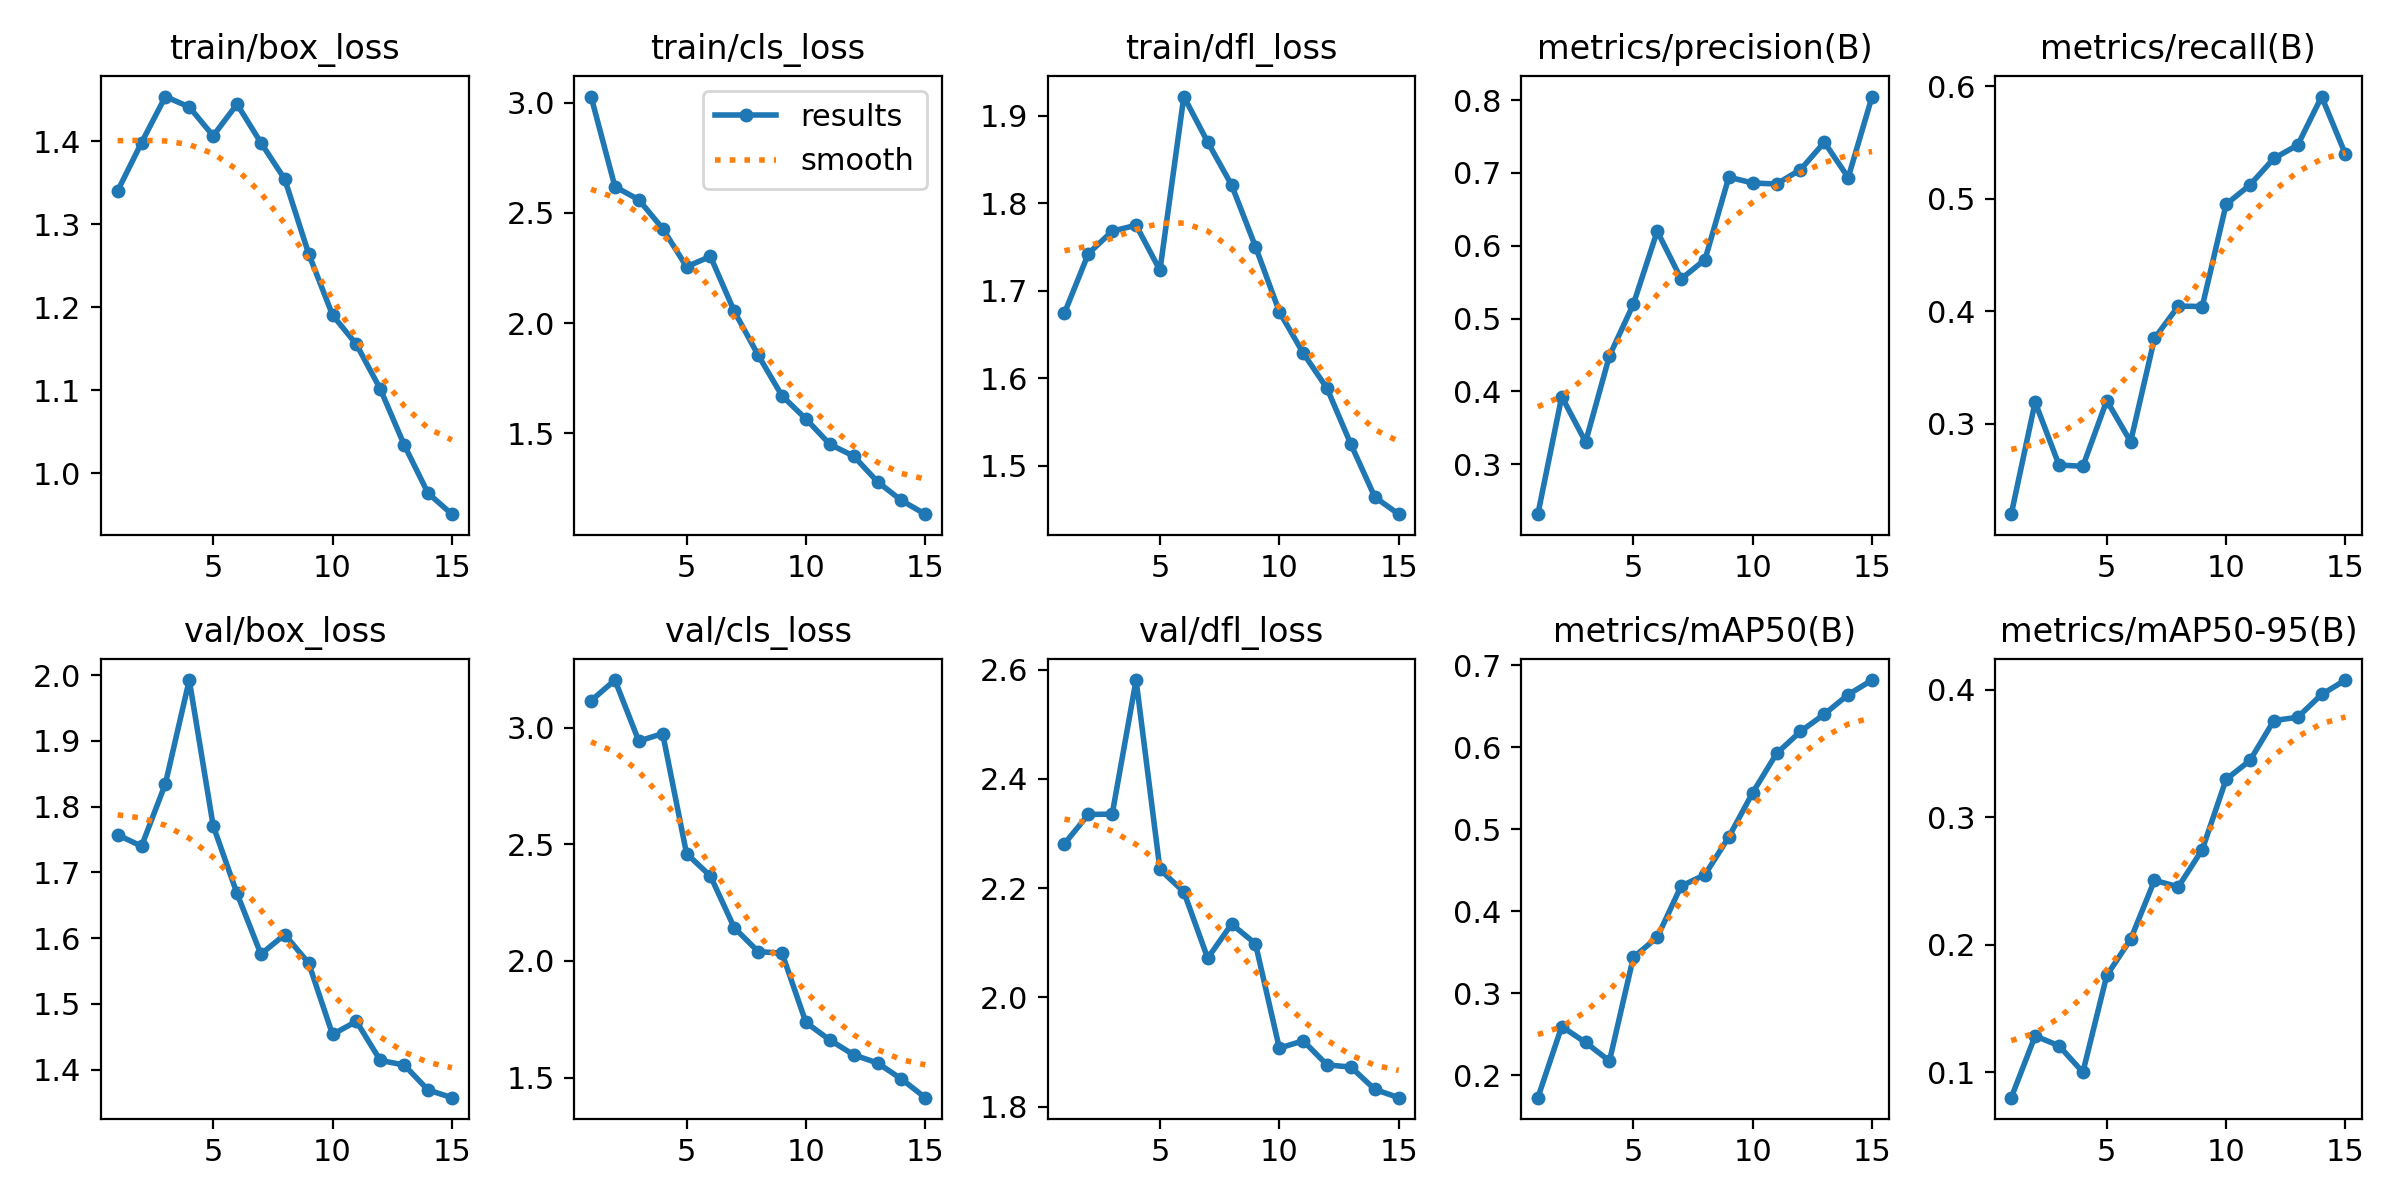


 confusion_matrix.png


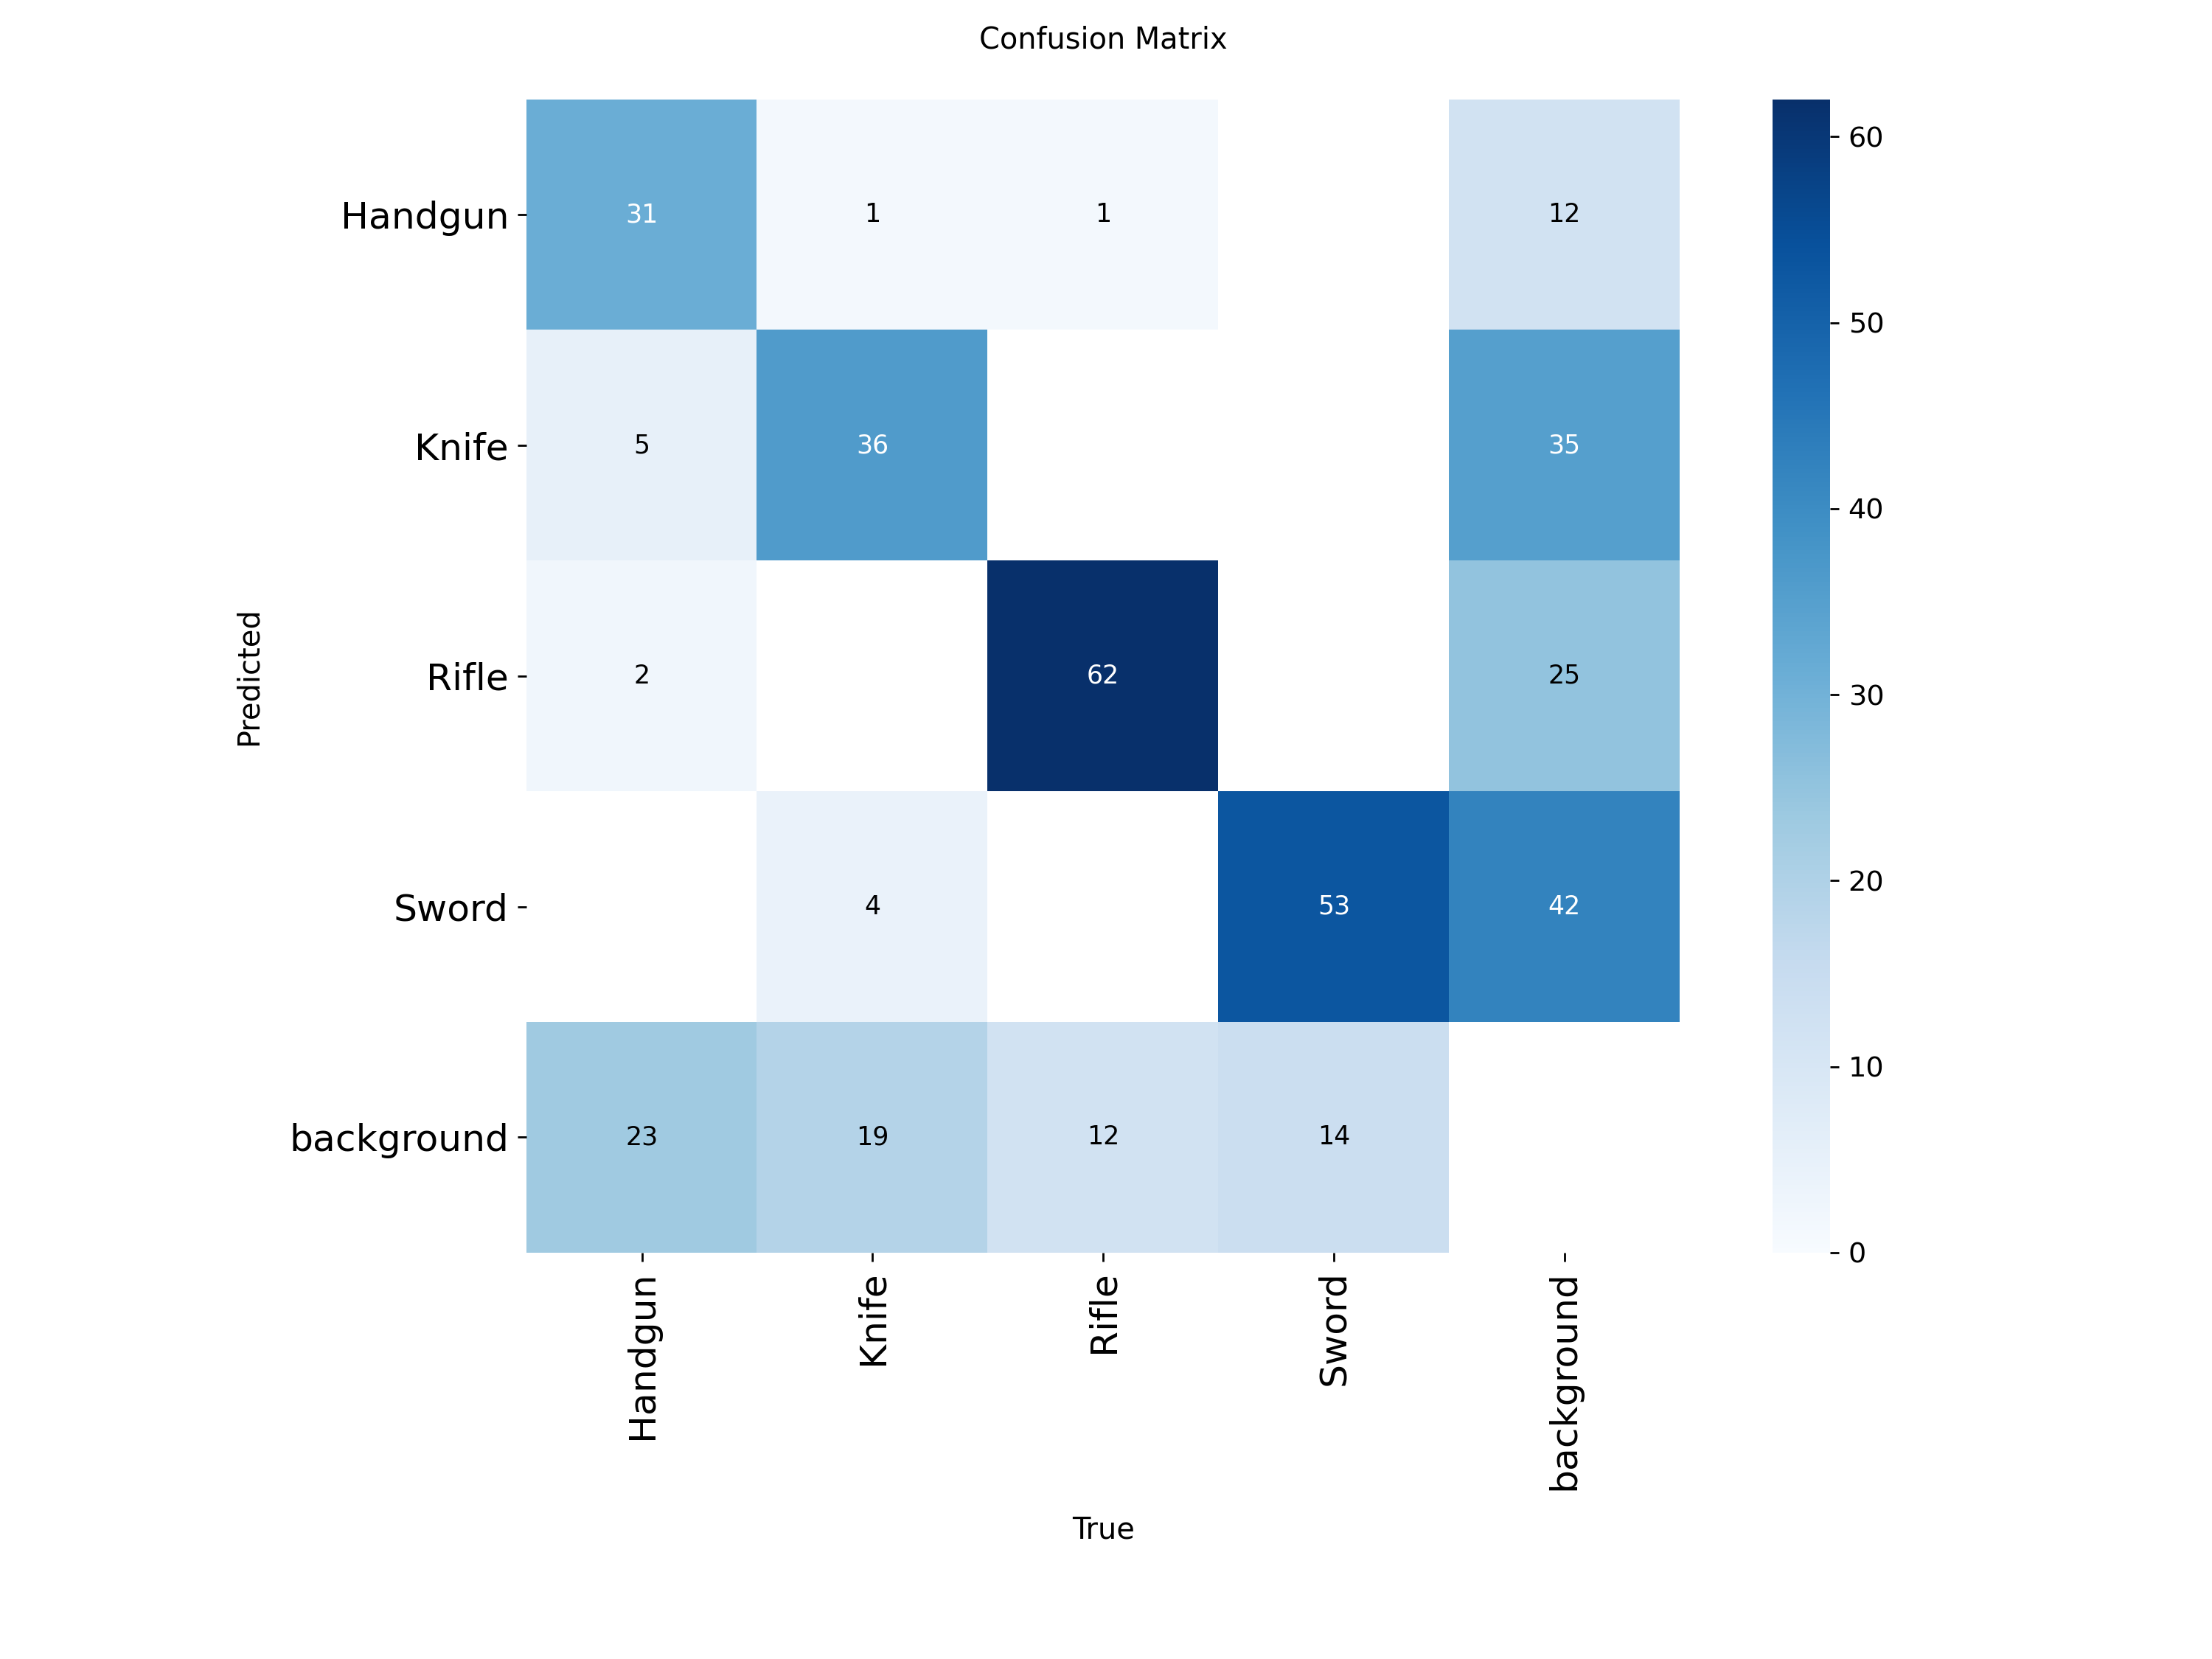

Not found: PR_curve.png
Not found: F1_curve.png
Not found: P_curve.png
Not found: R_curve.png


In [ ]:
train_run_dir = "runs/detect/weapon_detection_yolov8_roboflow"

result_files = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]

for file in result_files:
    path = os.path.join(train_run_dir, file)
    if os.path.exists(path):
        print("\n", file)
        display(Image(filename=path, width=800))
    else:
        print("Not found:", file)

## Step 11: Validate the Trained Model

In [ ]:
best_model_path = os.path.join(train_run_dir, "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val(data=data_yaml_path)

print("Validation completed.")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1030.1±251.8 MB/s, size: 18.4 KB)
val: Scanning /content/weapon-detection-3/valid/labels.cache... 232 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232 88.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.4it/s 3.4s
                   all        232        263      0.804      0.539      0.683      0.409
               Handgun         59         61      0.832      0.405      0.573       0.37
                 Knife         56         60      0.739        0.4      0.547      0.292
                 Rifle         66         75      0.859      0.667      0.836       0.52
                 Sword         53         67      0.789      0.687      0.776      0.452
Speed: 2.6ms preprocess, 4.4ms inferen

## Step 12: Test on Roboflow Test Images

In [ ]:
test_results = best_model.predict(
    source=test_img_dir,
    conf=0.4,
    save=True,
    name="weapon_detection_test_predictions"
)

print("Prediction completed on test images.")


image 1/275 /content/weapon-detection-3/test/images/073354cba4d11b34_jpg.rf.0eb5f21faa5914c97eab04a07c126380.jpg: 640x640 2 Swords, 9.3ms
image 2/275 /content/weapon-detection-3/test/images/0b34b3483cc47a82_jpg.rf.a7ab004bee9f1ba7b1c0df5c1933a7af.jpg: 640x640 2 Swords, 7.2ms
image 3/275 /content/weapon-detection-3/test/images/145df260d0fdf32f_jpg.rf.ae42bb3d562f4ae15746a6b1f3bcae1a.jpg: 640x640 1 Sword, 7.2ms
image 4/275 /content/weapon-detection-3/test/images/15737bb9772b6c88_jpg.rf.a0701a5809f316a13c78a602d738aa49.jpg: 640x640 1 Sword, 7.2ms
image 5/275 /content/weapon-detection-3/test/images/1884f0bf543ba8f6_jpg.rf.f94334c323ca315ddd6da0f3b669f526.jpg: 640x640 1 Sword, 7.2ms
image 6/275 /content/weapon-detection-3/test/images/1d055090c5631b0d_jpg.rf.f3428029133d2400dc669d80652e5808.jpg: 640x640 2 Rifles, 7.2ms
image 7/275 /content/weapon-detection-3/test/images/2-111-_jpg.rf.b59f817e538cd65a2ffe79c951e652ef.jpg: 640x640 1 Rifle, 7.2ms
image 8/275 /content/weapon-detection-3/test/im

## Step 13: Display Test Prediction Images

Number of predicted images: 275


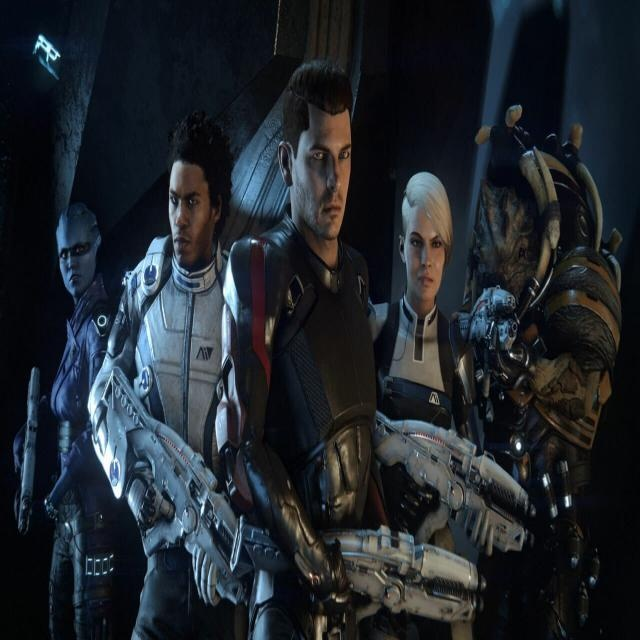

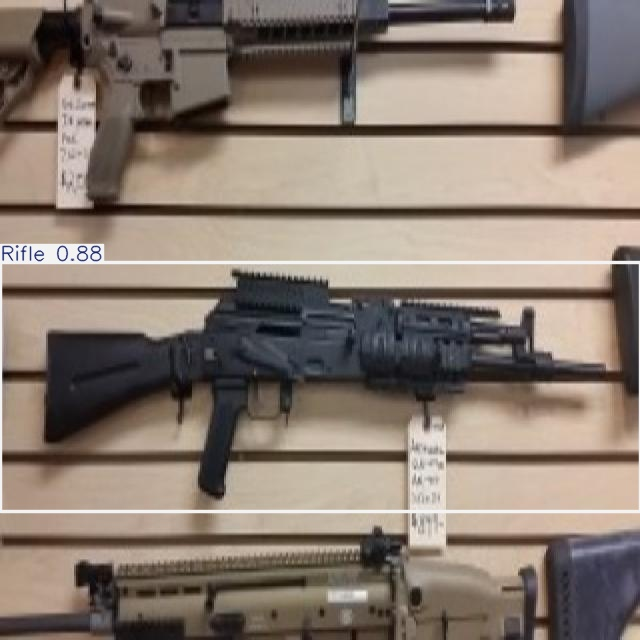

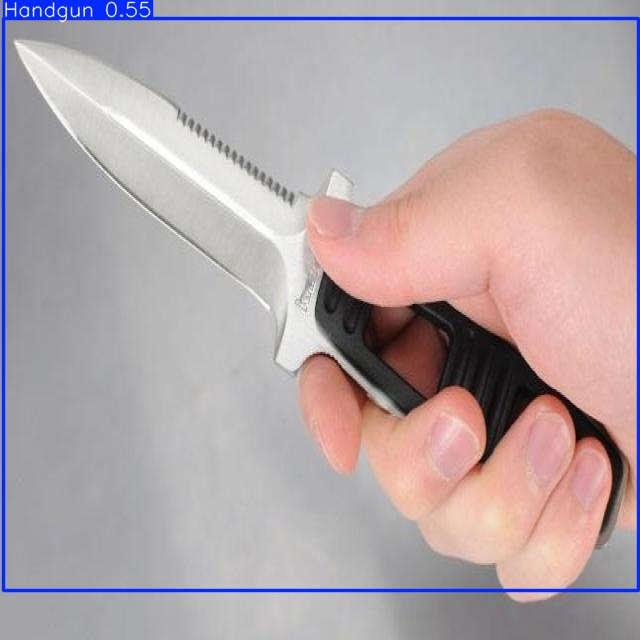

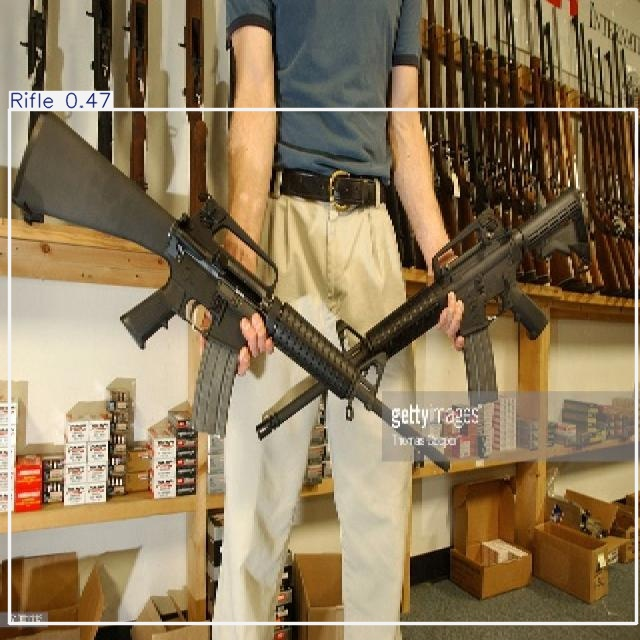

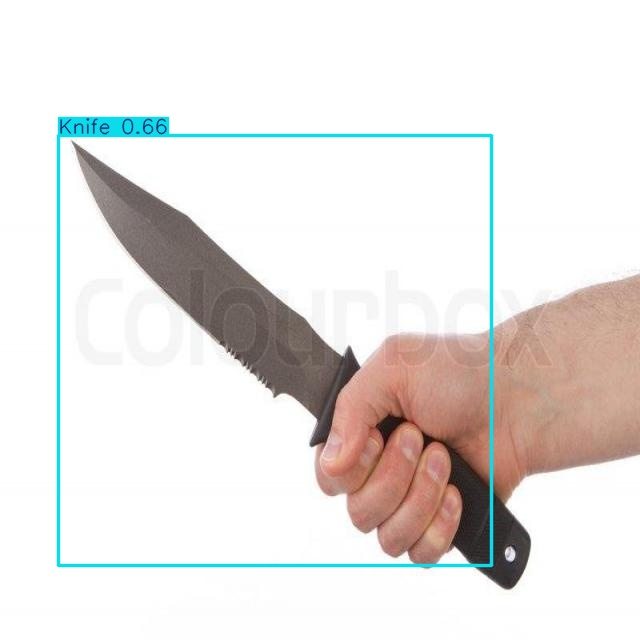

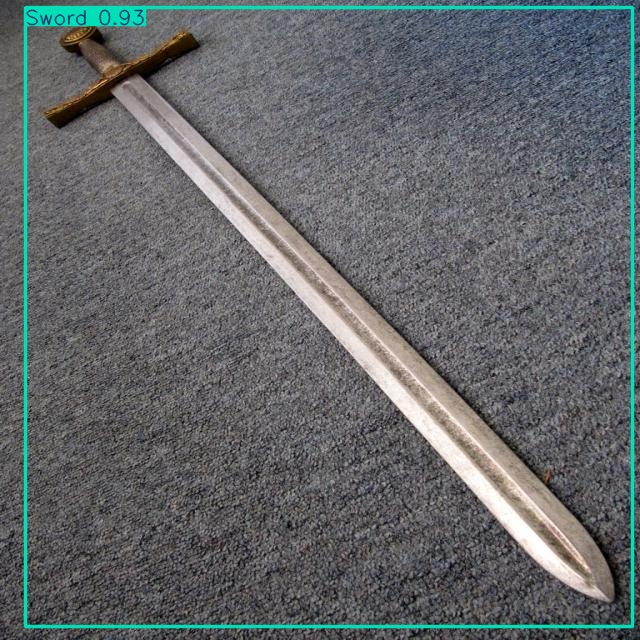

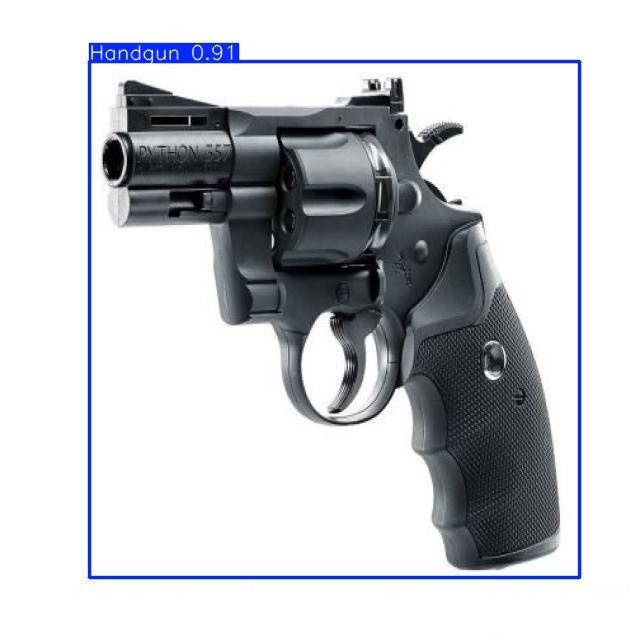

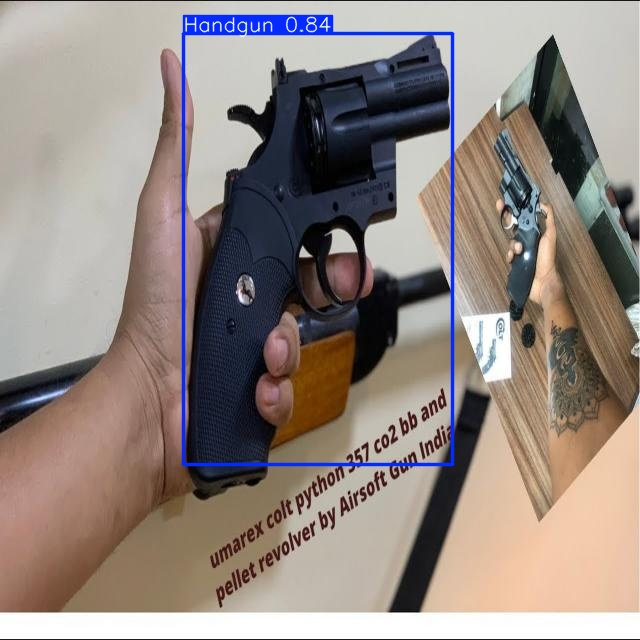

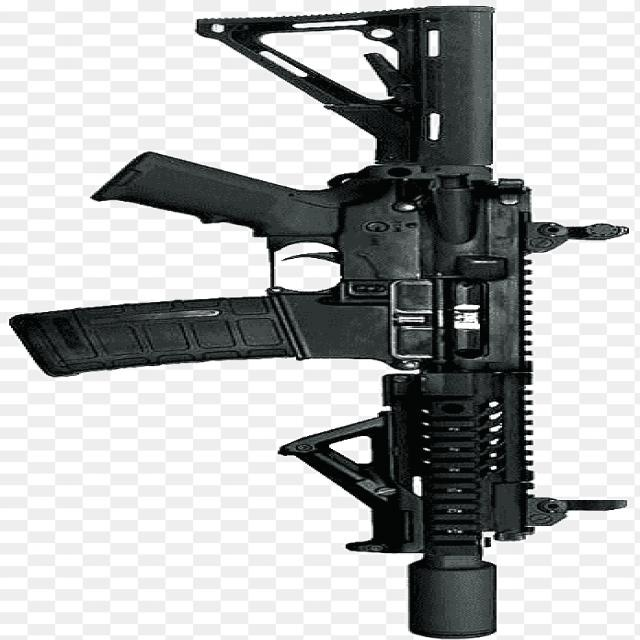

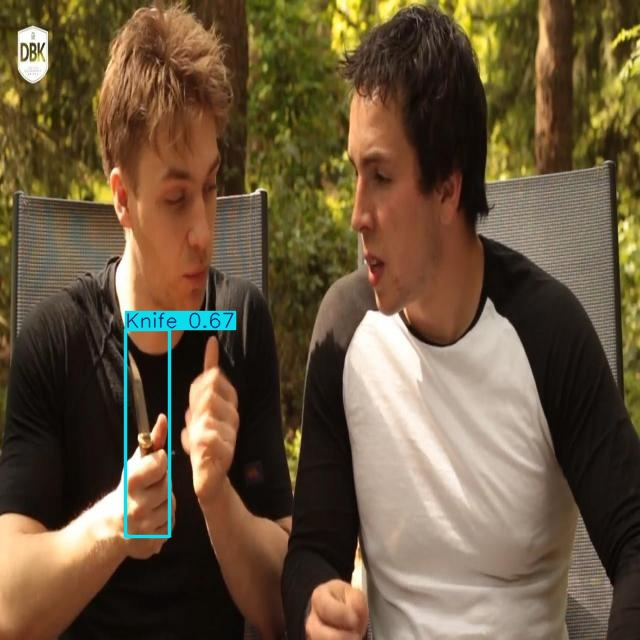

In [ ]:
prediction_dir = "runs/detect/weapon_detection_test_predictions"
predicted_images = glob.glob(os.path.join(prediction_dir, "*"))

print("Number of predicted images:", len(predicted_images))

for img in predicted_images[:10]:
    display(Image(filename=img, width=600))

## Step 14: Test on a New Uploaded Image

In [ ]:
uploaded = files.upload()
uploaded_image = list(uploaded.keys())[0]

single_result = best_model.predict(
    source=uploaded_image,
    conf=0.4,
    save=True,
    name="weapon_detection_uploaded_image"
)

print("Prediction completed on uploaded image.")

Saving download (7).jpg to download (7).jpg

image 1/1 /content/download (7).jpg: 448x640 1 Rifle, 44.3ms
Speed: 3.2ms preprocess, 44.3ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/weapon_detection_uploaded_image
Prediction completed on uploaded image.


## Step 15: Display Uploaded Image Prediction

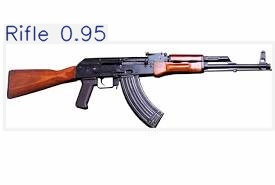

In [ ]:
uploaded_prediction_dir = "runs/detect/weapon_detection_uploaded_image"
uploaded_pred_images = glob.glob(os.path.join(uploaded_prediction_dir, "*"))

for img in uploaded_pred_images:
    display(Image(filename=img, width=700))

## Step 16: Extract Detected Object Names and Confidence Scores

In [ ]:
detections = []

for result in single_result:
    names = result.names

    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        label = names[cls_id]

        detections.append({
            "Detected Object": label,
            "Confidence Score": round(conf, 3)
        })

if len(detections) == 0:
    print("No weapon/object detected.")
else:
    display(pd.DataFrame(detections))

,Detected Object,Confidence Score
0,Rifle,0.955


## Step 17: Optional Video Testing

In [ ]:
# Optional video testing
# uploaded_video = files.upload()
# video_path = list(uploaded_video.keys())[0]

# video_results = best_model.predict(
#     source=video_path,
#     conf=0.4,
#     save=True,
#     name="weapon_detection_video"
# )

# print("Video prediction completed.")

In [ ]:
import glob

# Search all best.pt files inside runs folder
best_model_paths = glob.glob("/content/runs/**/best.pt", recursive=True)

print("Available best.pt model files:")
for i, path in enumerate(best_model_paths):
    print(i, path)

if len(best_model_paths) == 0:
    print("No best.pt found. Please train the model first.")
else:
    best_model_path = best_model_paths[-1]
    print("Using model:", best_model_path)

Available best.pt model files:
0 /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt
Using model: /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt


In [ ]:
!pip install yt-dlp -q

from ultralytics import YOLO
import glob
from IPython.display import HTML
from base64 import b64encode

# Automatically find best.pt
best_model_paths = glob.glob("/content/runs/**/best.pt", recursive=True)

if len(best_model_paths) == 0:
    raise FileNotFoundError("No best.pt found. Train your YOLO model first, then run this cell again.")

best_model_path = best_model_paths[-1]
print("Loaded model:", best_model_path)

best_model = YOLO(best_model_path)

# Paste video URL here
video_url = "https://www.youtube.com/shorts/UfphLS5MVKQ"

# Download video
video_path = "weapon_test_video.mp4"
!yt-dlp -f "mp4/best" -o "{video_path}" "{video_url}"

print("Video downloaded successfully:", video_path)

# Run prediction and save output
video_results = best_model.predict(
    source=video_path,
    conf=0.4,
    save=True,
    name="weapon_detection_video"
)

print("Video prediction completed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.6 MB/s eta 0:00:00
Loaded model: /content/runs/detect/weapon_detection_yolov8_roboflow/weights/best.pt
[youtube] Extracting URL: https://www.youtube.com/shorts/UfphLS5MVKQ
[youtube] UfphLS5MVKQ: Downloading webpage
[youtube] UfphLS5MVKQ: Downloading android vr player API JSON
[info] UfphLS5MVKQ: Downloading 1 format(s): 18
[download] Destination: weapon_test_video.mp4
[download] 100% of    4.27MiB in 00:00:00 at 9.46MiB/s
Video downloaded successfully: weapon_test_video.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes objec

In [ ]:
video_results = best_model.predict(
    source=video_path,
    conf=0.15,
    save=True,
    save_txt=True,
    save_conf=True,
    project="/content/runs/detect",
    name="weapon_detection_video",
    exist_ok=True
)

print("Prediction completed.")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1797) /content/weapon_test_video.mp4: 640x384 (no detections), 9.6ms
video 1/1 (frame 2/1797) /content/weapon_test_video.mp4: 640x384 (no detections), 7.3ms
video 1/1 (frame 3/1797) /content/weapon_test_video.mp4: 640x384 1 Rifle, 7.3ms
video 1/1 (frame 4/1797) /content/weapon_test_video.mp4: 640x384 1 Rifle, 6.8ms
video 1/1 (frame 5/1797) /content/weapon_test_video.mp4: 640x384 (no detections), 6.4ms
video 1/1 (frame 6/1797) /content/

# Student Report Questions

1. What is the objective of weapon detection?
2. Which dataset did you use from Roboflow?
3. What classes were present in your dataset?
4. How many images were used for training, validation, and testing?
5. Which YOLO model did you use?
6. What were the training parameters?
7. What were the precision, recall, mAP@0.5, and mAP@0.5:0.95 values?
8. Show 5 test results with bounding boxes.
9. Mention 5 limitations of the model.
10. Explain why human verification is required in AI-based weapon detection.

# Ethical Considerations

Students must mention:

- The system may produce false positives.
- The system may miss small, blurry, or hidden weapons.
- CCTV footage may be low quality.
- The model should not be used for unauthorized surveillance.
- Human verification is required before taking action.
- Dataset bias can affect performance.

# Final Conclusion Template

```text
In this lab, we trained a YOLO-based weapon detection model using a Roboflow dataset.
The model was able to detect classes such as __________ with confidence scores.
The performance was evaluated using precision, recall, and mAP.
Although the model can assist in security monitoring, it has limitations such as false positives, false negatives, low-light issues, and dataset bias.
Therefore, human verification is necessary before making any security decision.
```